In [6]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('grayscale')
plt.rc("figure", figsize=(16, 5))

In [3]:
df = pd.read_csv('nyc_taxi.csv',
                 index_col='timestamp',
                 parse_dates=True)
df.head()

,value
timestamp,
2014-07-01 00:00:00,10844
2014-07-01 00:30:00,8127
2014-07-01 01:00:00,6210
2014-07-01 01:30:00,4656
2014-07-01 02:00:00,3820


<Axes: xlabel='timestamp'>

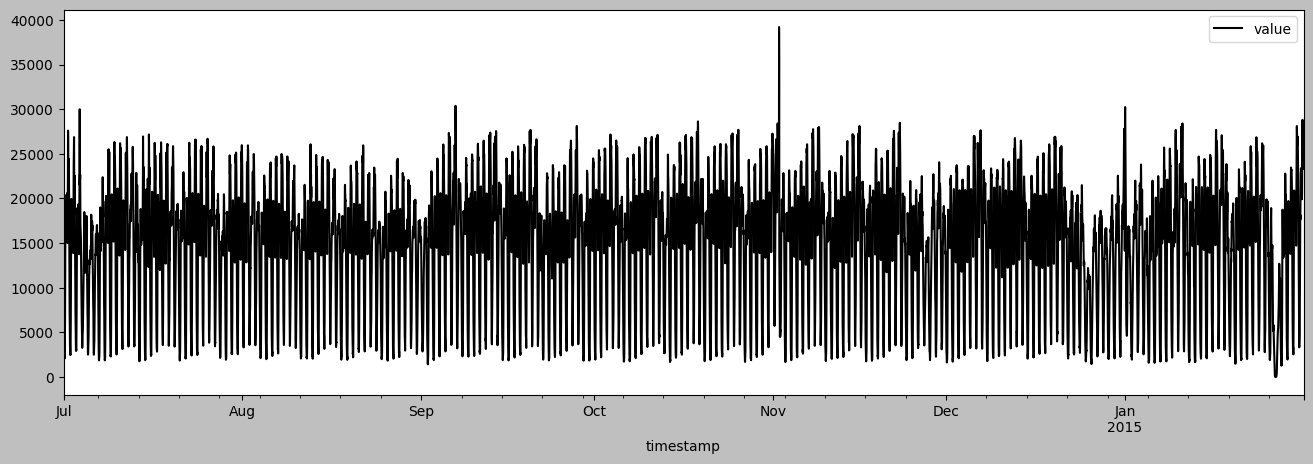

In [7]:
df.plot()

In [8]:
df.index.freq = '30min'

In [10]:
df.index

DatetimeIndex(['2014-07-01 00:00:00', '2014-07-01 00:30:00',
               '2014-07-01 01:00:00', '2014-07-01 01:30:00',
               '2014-07-01 02:00:00', '2014-07-01 02:30:00',
               '2014-07-01 03:00:00', '2014-07-01 03:30:00',
               '2014-07-01 04:00:00', '2014-07-01 04:30:00',
               ...
               '2015-01-31 19:00:00', '2015-01-31 19:30:00',
               '2015-01-31 20:00:00', '2015-01-31 20:30:00',
               '2015-01-31 21:00:00', '2015-01-31 21:30:00',
               '2015-01-31 22:00:00', '2015-01-31 22:30:00',
               '2015-01-31 23:00:00', '2015-01-31 23:30:00'],
              dtype='datetime64[ns]', name='timestamp', length=10320, freq='30min')

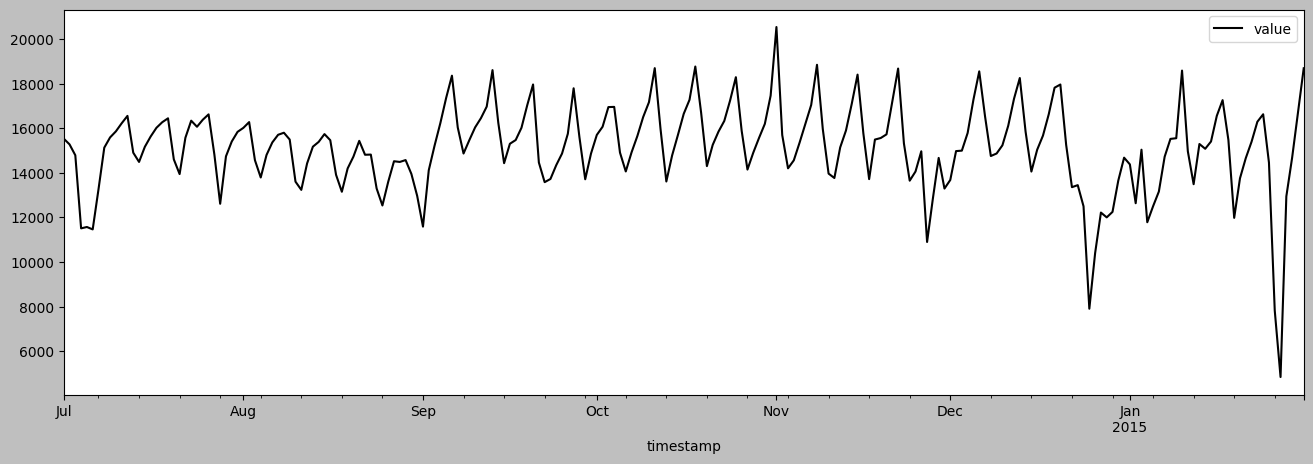

In [15]:
df_resampled = df.resample('D').mean().plot()

In [13]:
nyc_dates =  [
        "2014-11-01",
        "2014-11-27",
        "2014-12-25",
        "2015-01-01",
        "2015-01-27"
]

In [21]:
df_resampled = df.resample('D').mean()

nyc_dates =  [
        "2014-11-01",
        "2014-11-27",
        "2014-12-25",
        "2015-01-01",
        "2015-01-27"
]

known_outliers = df_resampled.loc[nyc_dates]

In [14]:
def plot_outliers(outliers, data, method='KNN', halignment='right', valignment='bottom', labels=False):
    
    fig, ax = plt.subplots(figsize=(10, 6))
        
    data.plot(ax=ax, alpha=0.6)
    
    # Plot outliers
    if labels:
        outliers.plot(ax=ax, style='rx', markersize=8, legend=False)
        
        # Add text labels for each outlier
        for idx, value in outliers['value'].items():
            ax.text(idx, value, f'{idx.date()}', 
                   horizontalalignment=halignment, 
                   verticalalignment=valignment)
    else:
        outliers.plot(ax=ax, style='rx', legend=False)
    
    ax.set_title(f'NYC Taxi - {method}')
    ax.set_xlabel('date')
    ax.set_ylabel('# of passengers')
    ax.legend(['nyc taxi', 'outliers'])
    
    plt.tight_layout()
    plt.show()

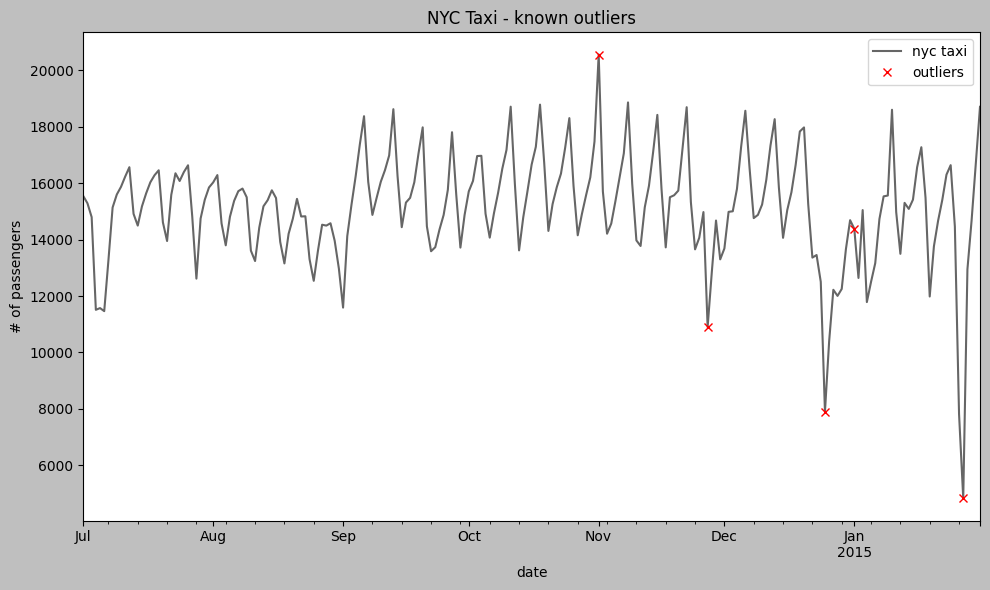

In [22]:
plot_outliers(known_outliers, df_resampled, "known outliers")

In [18]:
! uv pip install seaborn

Using Python 3.12.1 environment at: /workspaces/TechCatalyst_DE_2025_3/dev1
Resolved 15 packages in 911ms                                        
⠙ Preparing packages... (0/1)                                                   
⠙ Preparing packages... (0/1)--------------     0 B/288.00 KiB          
⠙ Preparing packages... (0/1)-------------- 16.00 KiB/288.00 KiB        
⠙ Preparing packages... (0/1)-------------- 32.00 KiB/288.00 KiB        
⠙ Preparing packages... (0/1)-------------- 48.00 KiB/288.00 KiB        
⠙ Preparing packages... (0/1)-------------- 63.04 KiB/288.00 KiB        
⠙ Preparing packages... (0/1)-------------- 79.04 KiB/288.00 KiB        
⠙ Preparing packages... (0/1)-------------- 95.04 KiB/288.00 KiB        
⠙ Preparing packages... (0/1)-------------- 111.04 KiB/288.00 KiB       
⠙ Preparing packages... (0/1)-------------- 127.04 KiB/288.00 KiB       
⠙ Preparing packages... (0/1)-------------- 143.04 KiB/288.00 KiB       
⠙ Preparing packages... (0/1)m-------------

In [24]:
import seaborn as sns

<Axes: >

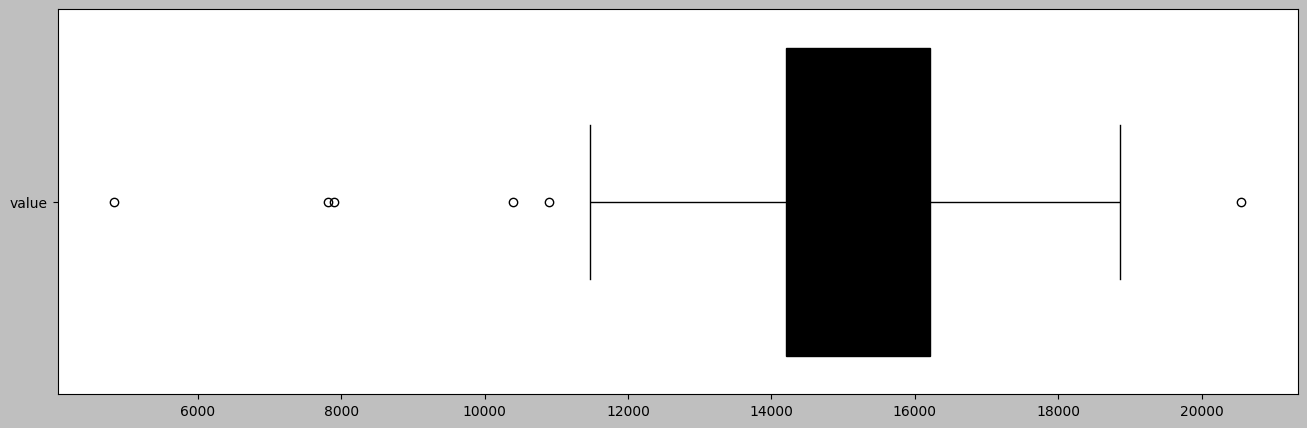

In [25]:
sns.boxplot(df_resampled, orient='h')

In [26]:
import numpy as np

In [29]:
q1, q3 = np.percentile(df_resampled, [25, 75])
IQR = q3 - q1
lower_fence = q1 - (1.5 * IQR)
upper_fence = q3 + (1.5 * IQR)

In [31]:
outliers = df_resampled[(df_resampled['value'] > upper_fence) | (df_resampled['value'] < lower_fence)]

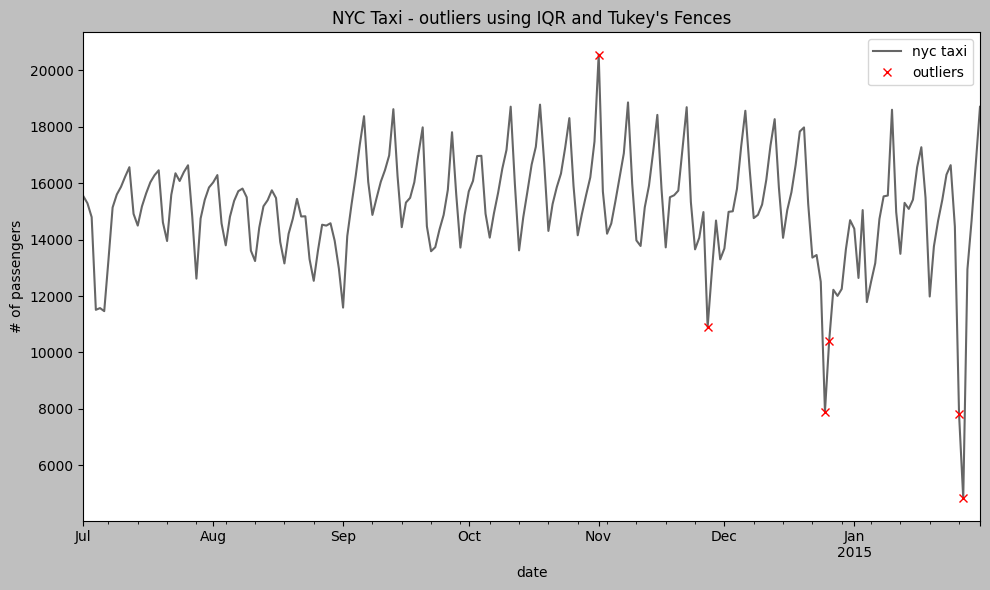

In [32]:
plot_outliers(outliers, df_resampled, "outliers using IQR and Tukey's Fences")

In [33]:
!uv pip install pyod

Using Python 3.12.1 environment at: /workspaces/TechCatalyst_DE_2025_3/dev1
Resolved 18 packages in 721ms                                        
⠙ Preparing packages... (0/4)                                                   
⠙ Preparing packages... (0/4)--------------     0 B/195.93 KiB          
⠙ Preparing packages... (0/4)-------------- 16.00 KiB/195.93 KiB        
⠙ Preparing packages... (0/4)-------------- 32.00 KiB/195.93 KiB        
⠙ Preparing packages... (0/4)-------------- 48.00 KiB/195.93 KiB        
⠙ Preparing packages... (0/4)-------------- 64.00 KiB/195.93 KiB        
⠙ Preparing packages... (0/4)-------------- 64.00 KiB/195.93 KiB        
pyod                 ------------------------------ 64.00 KiB/195.93 KiB
⠙ Preparing packages... (0/4)--------------     0 B/15.76 MiB           
pyod                 ------------------------------ 64.00 KiB/195.93 KiB
⠙ Preparing packages... (0/4)--------------     0 B/15.76 MiB           
pyod                 ----------------------

In [34]:
from pyod.models.knn import KNN
from pyod.models.iforest import IForest

In [44]:
iforest = IForest(contamination=0.03)
iforest.fit(df_resampled)
iforest_pred = pd.Series(iforest.predict(df_resampled), index=df_resampled.index)

/workspaces/TechCatalyst_DE_2025_3/dev1/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


In [45]:
iforest_pred

timestamp
2014-07-01    0
2014-07-02    0
2014-07-03    0
2014-07-04    0
2014-07-05    0
             ..
2015-01-27    1
2015-01-28    0
2015-01-29    0
2015-01-30    0
2015-01-31    0
Freq: D, Length: 215, dtype: int64

In [49]:
iforest_outliers = iforest_pred[iforest_pred == 1]
df_resampled.loc[iforest_outliers.index]

,value
timestamp,
2014-11-01,20553.500000
2014-11-08,18857.333333
2014-11-27,10899.666667
2014-12-25,7902.125000
2014-12-26,10397.958333
2015-01-26,7818.979167
2015-01-27,4834.541667


In [50]:
nyc_dates

['2014-11-01', '2014-11-27', '2014-12-25', '2015-01-01', '2015-01-27']

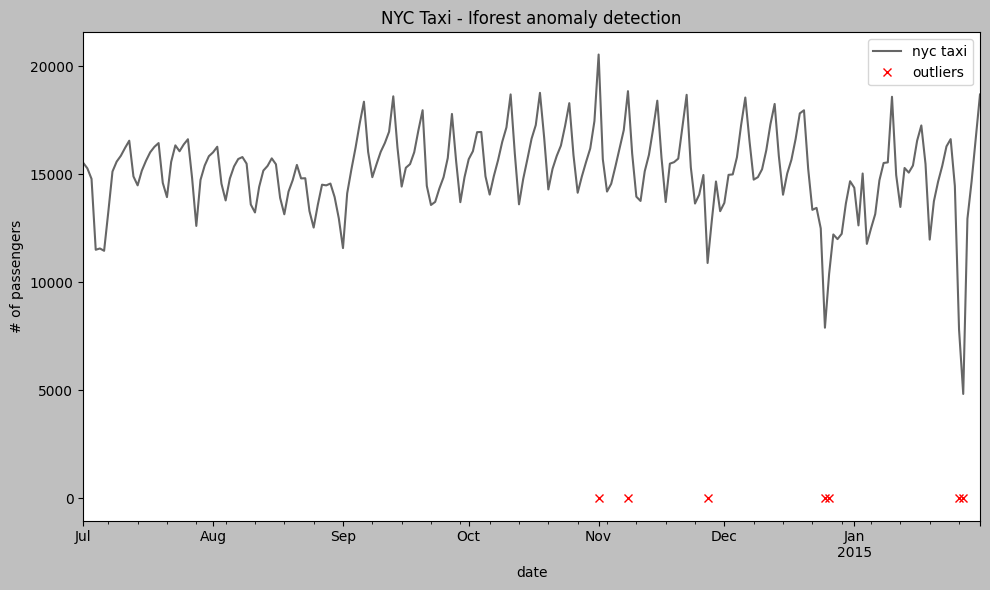

In [51]:
plot_outliers(iforest_outliers, df_resampled, 'Iforest anomaly detection')